# MATLAB to PyTorch Conversion: H₂ Biogeochemical Reactive Transport Model

**Original MATLAB Code:** `rnn_transport_multiguild_uq_v3.m`

This script is a **strict 1:1 conversion** from MATLAB to PyTorch.
Every section maps directly to the original MATLAB code.

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Part 1: Imports

**MATLAB equivalent:** Automatic (no explicit imports needed)

In [29]:
# Core libraries
import numpy as np
import pandas as pd

# Scientific computing
from scipy.optimize import least_squares  # MATLAB: lsqnonlin
from scipy.integrate import solve_ivp     # MATLAB: ode45

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Visualization
import matplotlib.pyplot as plt

# Utilities
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Part 2: Data Loading

**MATLAB lines 8-15:**
```matlab
raw = readmatrix('Muller_2024_H2_Sandstone_at_25C.txt');
t_exp = raw(:,1);
data_exp = [raw(:,2:5)*1e-3, raw(:,7)];
x0 = [data_exp(1,:)'; 0.01; 0.01; 0.01; 0; 0];
```

In [30]:
# MATLAB: readmatrix()
raw = np.loadtxt('/content/drive/MyDrive/chemical_thesis_repo/reactions/Matlab_codes_My_work/Muller_2024_H2_Sandstone_at_25C.txt', skiprows=2, encoding='latin-1')

# MATLAB: t_exp = raw(:,1)
t_exp = raw[:, 0]

# MATLAB: data_exp = [raw(:,2:5)*1e-3, raw(:,7)]
conc_micromol = raw[:, 1:5] * 1e-3
so4_mmol = raw[:, 6:7]
data_exp = np.hstack([conc_micromol, so4_mmol])

# MATLAB: x0 = [data_exp(1,:)'; 0.01; 0.01; 0.01; 0; 0]
x0 = np.concatenate([data_exp[0, :], np.array([0.01, 0.01, 0.01, 0.01, 0.0])])

print(f'Loaded {len(t_exp)} experimental time points')
print(f'Initial conditions: {x0}')

Loaded 11 experimental time points
Initial conditions: [9.096e+00 2.459e+00 0.000e+00 1.000e-03 5.100e+00 1.000e-02 1.000e-02
 1.000e-02 1.000e-02 0.000e+00]


## Part 3: ODE Model

**MATLAB lines 225-291:** `trueODEfunc_multiguild`

In [31]:
def ode_multiguild(t, y, p):
    """
    MATLAB: trueODEfunc_multiguild (lines 225-291)
    """
    # Unpack state variables
    H2, CO2, CH4, H2S, SO4, FeS, X_meth, X_sulf, X_aceto, Acetate = y

    # Unpack parameters
    k_meth, k_sulf, k_aceto = p[0:3]
    Y_m, Y_s, Y_a = p[3:6]
    KI_meth, KI_sulf, KI_aceto = p[6:9]
    k_precip, H2S_sat, H2_thresh = p[9:12]
    DG_thresh = p[12]

    # Constants
    R = 8.314e-3
    T = 298.15
    RT = R * T
    DG0_meth = -130
    DG0_sulf = -152
    DG0_aceto = -95

    # Inhibition
    f_inh_meth = KI_meth / (KI_meth + H2S)
    f_inh_sulf = KI_sulf / (KI_sulf + H2S)
    f_inh_aceto = KI_aceto / (KI_aceto + H2S)

    # Activation
    f_activation = H2 / (H2 + H2_thresh)

    # Prevent log(0)
    H2 = np.maximum(H2, 1e-6)
    CO2 = np.maximum(CO2, 1e-6)
    CH4 = np.maximum(CH4, 1e-6)
    SO4 = np.maximum(SO4, 1e-6)
    H2S = np.maximum(H2S, 1e-6)
    Acetate = np.maximum(Acetate, 1e-6)

    # Reaction quotients
    Q_meth = CH4 / (H2**4 * CO2)
    Q_sulf = H2S / (H2**4 * SO4)
    Q_aceto = Acetate / (H2**4 * CO2**2)

    # Gibbs energies
    DG_meth = DG0_meth + RT * np.log(Q_meth)
    DG_sulf = DG0_sulf + RT * np.log(Q_sulf)
    DG_aceto = DG0_aceto + RT * np.log(Q_aceto)

    # Thermodynamic feasibility
    f_thermo_meth = 1.0 / (1.0 + np.exp((DG_meth - DG_thresh) / RT))
    f_thermo_sulf = 1.0 / (1.0 + np.exp((DG_sulf - DG_thresh) / RT))
    f_thermo_aceto = 1.0 / (1.0 + np.exp((DG_aceto - DG_thresh) / RT))

    # Reaction rates
    r_meth = k_meth * H2 * (CO2**-2) * f_inh_meth * f_activation * f_thermo_meth
    r_sulf = k_sulf * H2 * SO4 * f_inh_sulf * f_activation * f_thermo_sulf
    r_aceto = k_aceto * H2 * (CO2**2) * f_inh_aceto * f_activation * f_thermo_aceto

    # Precipitation
    r_precip = k_precip * np.maximum(0, H2S - H2S_sat)

    # Differential equations
    dH2 = -4 * r_meth - 4 * r_sulf - 4 * r_aceto
    dCO2 = -1 * r_meth - 2 * r_aceto
    dCH4 = +1 * r_meth
    dH2S = +1 * r_sulf - r_precip
    dSO4 = -1 * r_sulf
    dFeS = +1 * r_precip
    dX_meth = Y_m * r_meth
    dX_sulf = Y_s * r_sulf
    dX_aceto = Y_a * r_aceto
    dAcetate = +1 * r_aceto

    return np.array([dH2, dCO2, dCH4, dH2S, dSO4, dFeS, dX_meth, dX_sulf, dX_aceto, dAcetate])

print('ODE function defined')

ODE function defined


## Part 4: Parameter Fitting

**MATLAB lines 193-221:** `fit_mechanistic_params` and `residuals_multiguild`

In [32]:
def compute_residuals(p, t_exp, data_exp, x0):
    """
    MATLAB: residuals_multiguild (lines 204-221)
    """
    try:
        # MATLAB: ode45
        sol = solve_ivp(
            fun=lambda t, y: ode_multiguild(t, y, p),
            t_span=(t_exp[0], t_exp[-1]),
            y0=x0,
            t_eval=t_exp,
            method='RK45'
        )

        # MATLAB: y_sim = interp1(...)
        y_sim = sol.y[:5, :].T

        # MATLAB: log_sim = log1p(y_sim(:,1:5))
        log_sim = np.log1p(y_sim)
        log_exp = np.log1p(data_exp)

        # MATLAB: weights = [1, 1, 0.5, 0.5, 1]
        weights = np.array([1.0, 1.0, 0.5, 0.5, 1.0])
        res = (log_sim - log_exp) * weights

        # MATLAB: penalty for negative values
        if np.any(sol.y < -1e-6):
            res = res + 1e3 * np.abs(np.min(sol.y))

        return res.ravel()
    except:
        return 1e6 * np.ones(data_exp.size)


def fit_parameters(t_exp, data_exp, x0):
    """
    MATLAB: fit_mechanistic_params (lines 193-201)
    """
    # MATLAB: p0, lb, ub
    p0 = np.array([1.0, 1.0, 1.0, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, -10.0])
    lb = np.array([0.001, 0.001, 0.001, 0.01, 0.01, 0.01, 0.001, 0.001, 0.001, 0.0, 0.0, 0.0, -50.0])
    ub = np.array([10.0, 10.0, 10.0, 0.5, 0.5, 0.5, 10.0, 10.0, 10.0, 1.0, 1.0, 1.0, 0.0])

    # MATLAB: lsqnonlin
    result = least_squares(
        fun=lambda p: compute_residuals(p, t_exp, data_exp, x0),
        x0=p0,
        bounds=(lb, ub),
        verbose=2,
        max_nfev=5000
    )

    print(f'\nFitting complete. Cost: {result.cost:.6f}')
    return result.x


# MATLAB: line 18
p_fit = fit_parameters(t_exp, data_exp, x0)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.2901e+01                                    8.96e+00    
       1              2         8.5439e+00      4.36e+00       9.82e+00       1.28e+00    
       2              3         5.7200e+00      2.82e+00       7.19e-01       6.19e+02    
       3              4         4.7266e+00      9.93e-01       1.74e-02       1.54e+02    
       4              5         4.6069e+00      1.20e-01       2.26e-01       2.21e+02    
       5              6         4.4961e+00      1.11e-01       1.15e-01       1.92e+02    
       6              7         4.3888e+00      1.07e-01       7.51e-03       7.43e-01    
       7              8         3.9978e+00      3.91e-01       3.60e-01       9.25e+02    
       8              9         3.5605e+00      4.37e-01       5.91e-03       8.95e+01    
       9             10         3.4205e+00      1.40e-01       1.41e+00       7.00e+01    

## Part 5: Generate Training Data

**MATLAB lines 19-21:**
```matlab
t = linspace(0, t_exp(end), 2000);
[~, xTrain] = ode45(@(t,y) trueODEfunc_multiguild(t,y,p_fit), t, x0);
xTrain = xTrain';
```

In [33]:
# MATLAB: linspace
t_train = np.linspace(t_exp[0], t_exp[-1], 2000)

# MATLAB: ode45
sol = solve_ivp(
    fun=lambda t, y: ode_multiguild(t, y, p_fit),
    t_span=(t_train[0], t_train[-1]),
    y0=x0,
    t_eval=t_train,
    method='RK45'
)

# MATLAB: xTrain = xTrain'
x_train = sol.y  # [10, 2000]

print(f'Training data shape: {x_train.shape}')

Training data shape: (10, 2000)


## Part 6: Prepare Sequences

**MATLAB lines 50-61:**
```matlab
sequenceLength = 10;
X = {}; Y = [];
for i = 1:(size(xTrain,2) - sequenceLength)
    X{end+1} = xTrain(:, i:i+sequenceLength-1);
    Y(end+1, :) = xTrain(:, i+sequenceLength)';
end
```

In [34]:
class SequenceDataset(Dataset):
    """
    MATLAB: Creates X (cell array) and Y (matrix)
    """
    def __init__(self, data, sequence_length=10):
        self.sequence_length = sequence_length
        self.data = torch.FloatTensor(data.T)  # [2000, 10]
        self.n_samples = self.data.shape[0] - sequence_length

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # MATLAB: X{i} = xTrain(:, i:i+sequenceLength-1)
        x = self.data[idx:idx+self.sequence_length, :]
        # MATLAB: Y(i,:) = xTrain(:, i+sequenceLength)'
        y = self.data[idx+self.sequence_length, :]
        return x, y


# MATLAB: sequenceLength = 10
dataset = SequenceDataset(x_train, sequence_length=10)

# MATLAB: MiniBatchSize = 64
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f'Dataset size: {len(dataset)} sequences')

Dataset size: 1990 sequences


## Part 7: LSTM Model

**MATLAB lines 64-70:**
```matlab
layers = [
    sequenceInputLayer(10)
    dropoutLayer(0.2)
    lstmLayer(64, 'OutputMode', 'last')
    dropoutLayer(0.2)
    fullyConnectedLayer(10)
    regressionLayer
];
```

In [35]:
class ChemicalLSTM(nn.Module):
    """
    MATLAB: layers array (lines 64-70)
    """
    def __init__(self, input_size=10, hidden_size=64, output_size=10):
        super().__init__()
        # MATLAB: dropoutLayer(0.2)
        self.dropout1 = nn.Dropout(0.2)
        # MATLAB: lstmLayer(64, 'OutputMode', 'last')
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        # MATLAB: dropoutLayer(0.2)
        self.dropout2 = nn.Dropout(0.2)
        # MATLAB: fullyConnectedLayer(10)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.dropout1(x)
        lstm_out, _ = self.lstm(x)
        # MATLAB: 'OutputMode', 'last'
        last_output = lstm_out[:, -1, :]
        last_output = self.dropout2(last_output)
        output = self.fc(last_output)
        return output


model = ChemicalLSTM().to(device)
print(model)

ChemicalLSTM(
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(10, 64, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)


## Part 8: Training

**MATLAB lines 72-77:**
```matlab
options = trainingOptions('adam',
    'MaxEpochs', 300,
    'MiniBatchSize', 64,
    'InitialLearnRate', 1e-3,
    'Shuffle', 'every-epoch',
    'Verbose', false);
net = trainNetwork(X, Y, layers, options);
```

In [36]:
# MATLAB: regressionLayer
criterion = nn.MSELoss()

# MATLAB: trainingOptions('adam', 'InitialLearnRate', 1e-3)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# MATLAB: 'MaxEpochs', 300
num_epochs = 300

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for sequences, targets in train_loader:
        sequences = sequences.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 50 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')

print('Training complete')

Epoch [50/300], Loss: 0.028579
Epoch [100/300], Loss: 0.024199
Epoch [150/300], Loss: 0.022287
Epoch [200/300], Loss: 0.019085
Epoch [250/300], Loss: 0.015276
Epoch [300/300], Loss: 0.013424
Training complete


## Part 9: Save Model

**MATLAB line 80:**
```matlab
save('trained_LSTM_multiguild.mat', 'net');
```

In [37]:
# MATLAB: save
torch.save(model.state_dict(), 'trained_lstm_pytorch_after_conversion.pth')
print('Model saved to trained_lstm_pytorch.pth')

Model saved to trained_lstm_pytorch.pth


## Part 10: Reactive Transport Simulation

**MATLAB lines 87-118:** Transport parameters and initialization

In [38]:
# MATLAB: lines 87-100
L = 75
nx = 75
cell_w = 1
S_time = int(t_exp[-1])
n = 0.3
q = 1
v = q / n
D = 0.3
dt = cell_w / v

# MATLAB: lines 108-111
cmob = np.zeros((nx, 6))
cimob = np.zeros((nx, 4))
cmob[:, 0:2] = 1e-4
cmob[:, 4] = 5e-5
cimob[:, 0:4] = 0.01

# MATLAB: lines 113-117
BTC_mean = np.zeros((0, 10))
sequenceLength = 10
historyBuffer = np.tile(x0.reshape(-1, 1), (1, sequenceLength))

model.eval()
print('Transport simulation initialized')

Transport simulation initialized


## Part 11: Transport Loop

**MATLAB lines 119-162:** Main simulation loop

In [39]:
for time in range(S_time + 1):
    # MATLAB: lines 121-127 - Advection
    cmob[1:, :] = cmob[:-1, :]
    cmob[0, :] = [1e-4, 1e-4, 0, 0, 5e-5, 0]

    # MATLAB: lines 132-138 - Dispersion
    Jd = (cmob[:-1, :] - cmob[1:, :]) / cell_w * D
    Jd = np.vstack([np.zeros((1, 6)), Jd, Jd[-1:, :]])
    cmob = cmob + dt / cell_w * (Jd[:-1, :] - Jd[1:, :])

    # MATLAB: lines 142-152 - Reaction
    cmat_ensemble = np.zeros((nx, 10, 20))

    for it in range(nx):
        currentState = np.hstack([cmob[it, :], cimob[it, :]]).reshape(-1, 1)
        historyBuffer = np.hstack([historyBuffer[:, 1:], currentState])

        with torch.no_grad():
            for s in range(20):
                input_seq = torch.FloatTensor(historyBuffer.T).unsqueeze(0).to(device)
                y_pred = model(input_seq).cpu().numpy().flatten()
                cmat_ensemble[it, :, s] = y_pred

    # MATLAB: lines 154-158
    cmat_mean = np.mean(cmat_ensemble, axis=2)
    cmob = cmat_mean[:, 0:6]
    cimob = cmat_mean[:, 6:10]

    # MATLAB: lines 160-161
    BTC_mean = np.vstack([BTC_mean, cmat_mean[24, :]])

    if time % 5 == 0:
        print(f'Time: {time}/{S_time}')

print('Transport simulation complete')

Time: 0/19
Time: 5/19
Time: 10/19
Time: 15/19
Transport simulation complete


## Part 12: Visualization

**MATLAB lines 164-189:** Plot breakthrough curves

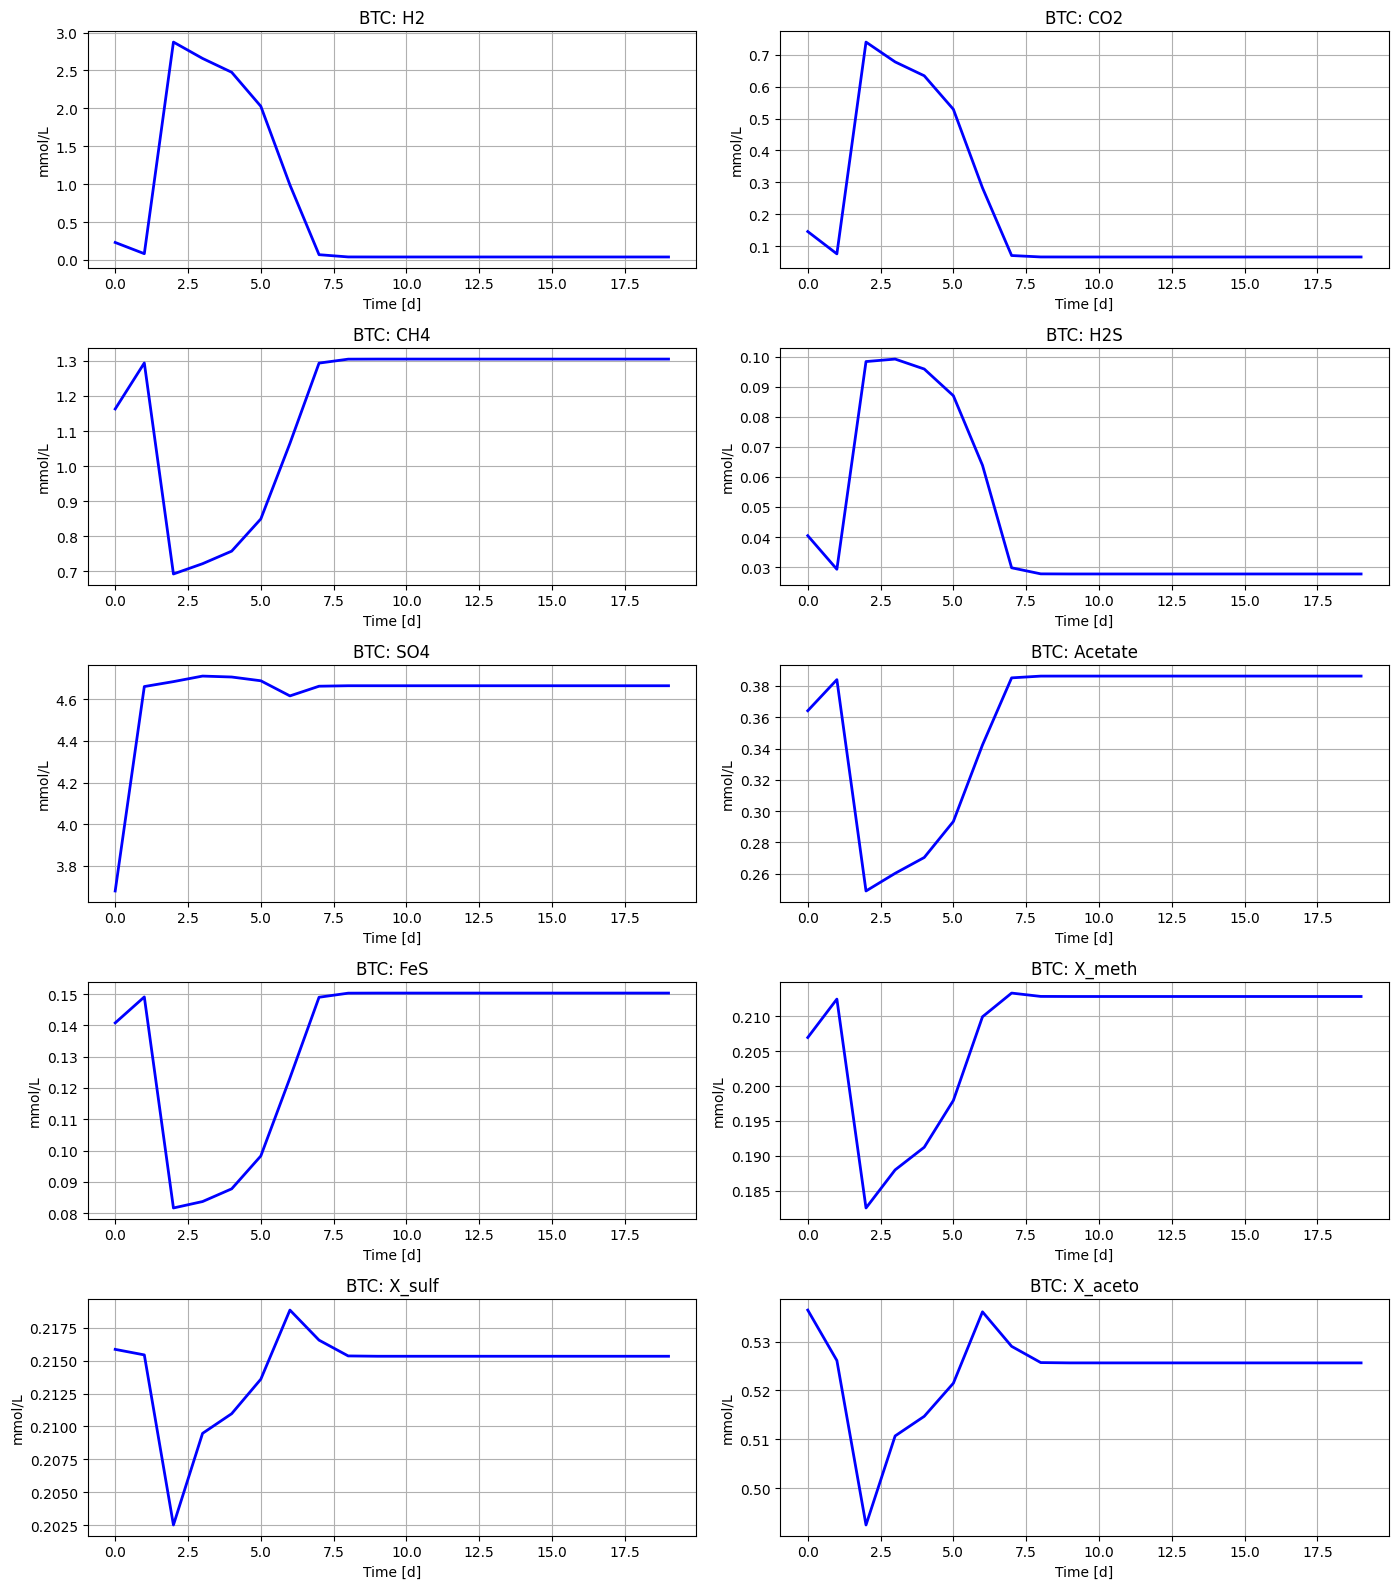

Breakthrough curves saved to breakthrough_curves.png

=== CONVERSION COMPLETE ===


In [40]:
# MATLAB: lines 165-166
tvec = np.arange(0, S_time + 1)
species = ['H2', 'CO2', 'CH4', 'H2S', 'SO4', 'Acetate', 'FeS', 'X_meth', 'X_sulf', 'X_aceto']

# MATLAB: lines 168-189
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.ravel()

for i in range(10):
    axes[i].plot(tvec, BTC_mean[:, i], 'b-', linewidth=2)
    axes[i].set_xlabel('Time [d]')
    axes[i].set_ylabel('mmol/L')
    axes[i].set_title(f'BTC: {species[i]}')
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('breakthrough_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Breakthrough curves saved to breakthrough_curves.png')
print('\n=== CONVERSION COMPLETE ===')